In [1]:
# %pip install -q datasets transformers evaluate accelerate scikit-learn pandas matplotlib seaborn emoji

In [2]:
import os
import gc
import time
import random
import numpy as np
import pandas as pd
import torch

from datasets import load_dataset
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, classification_report, confusion_matrix

# from .autonotebook import tqdm as notebook_tqdm

import matplotlib.pyplot as plt
import seaborn as sns

import evaluate

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
    set_seed
)

/home/experimental/miniconda3/envs/jupyter/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
TASK = "emotion"
SEED = 42

set_seed(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

Device: cuda


# Prepare Dataset (TweetEval - Emotion Task)

In [4]:
dataset = load_dataset("cardiffnlp/tweet_eval", TASK)
dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 3257
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 1421
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 374
    })
})

In [5]:
label_names = dataset["train"].features["label"].names
num_labels = len(label_names)

print("Number of labels:", num_labels)
print("Labels:", label_names)

print(dataset["train"][0])

Number of labels: 4
Labels: ['anger', 'joy', 'optimism', 'sadness']
{'text': "“Worry is a down payment on a problem you may never have'. \xa0Joyce Meyer.  #motivation #leadership #worry", 'label': 2}


In [6]:
def preprocess_tweet(text):
    new_text = []
    for t in text.split():
        if len(t) > 1:
            t = "@user" if t.startswith("@") and t.count("@") == 1 else t
            t = "http" if t.startswith("http") else t
        new_text.append(t)
    return " ".join(new_text)

def add_preprocessed_text(batch):
    batch["text"] = [preprocess_tweet(t) for t in batch["text"]]
    return batch

dataset = dataset.map(add_preprocessed_text, batched=True)

label
anger       1400
sadness      855
joy          708
optimism     294
Name: count, dtype: int64

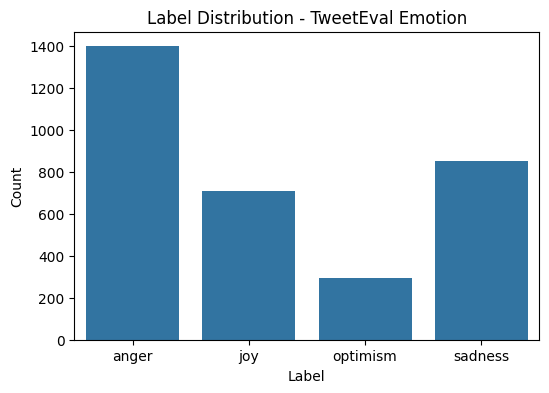

In [7]:
train_labels = dataset["train"]["label"]

df_dist = pd.DataFrame({
    "label_id": train_labels,
    "label": [label_names[i] for i in train_labels]
})

display(df_dist["label"].value_counts())

plt.figure(figsize=(6, 4))
sns.countplot(data=df_dist, x="label", order=label_names)
plt.title("Label Distribution - TweetEval Emotion")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()

# List of Experiments

In [8]:
MODEL_CONFIGS = [
    {
        "short_name": "Rob-rt",
        "hf_name": "roberta-base",
        "lr": 1e-5,
        "batch_size": 16,
        "epochs": 5,
        "max_length": 128,
    },
    {
        "short_name": "Rob-tw",
        "hf_name": "cardiffnlp/twitter-roberta-base",
        "lr": 1e-5,
        "batch_size": 16,
        "epochs": 5,
        "max_length": 128,
    },
    {
        "short_name": "XLM-r",
        "hf_name": "xlm-roberta-base",
        "lr": 1e-5,
        "batch_size": 16,
        "epochs": 5,
        "max_length": 128,
    },
    {
        "short_name": "XLM-tw",
        "hf_name": "cardiffnlp/twitter-xlm-roberta-base",
        "lr": 1e-5,
        "batch_size": 16,
        "epochs": 5,
        "max_length": 128,
    },
    {
        "short_name": "BERTweet",
        "hf_name": "vinai/bertweet-base",
        "lr": 1e-5,
        "batch_size": 16,
        "epochs": 5,
        "max_length": 128,
    },
    {
        "short_name": "TimeLM-19",
        "hf_name": "cardiffnlp/twitter-roberta-base-2019-90m",
        "lr": 1e-5,
        "batch_size": 16,
        "epochs": 5,
        "max_length": 128,
    },
    {
        "short_name": "TimeLM-21",
        "hf_name": "cardiffnlp/twitter-roberta-base-2021-124m",
        "lr": 1e-5,
        "batch_size": 16,
        "epochs": 5,
        "max_length": 128,
    },
    {
        "short_name": "Rob-bs",
        "hf_name": "roberta-base",
        "lr": 1e-5,
        "batch_size": 16,
        "epochs": 5,
        "max_length": 128,
    },
]

In [9]:
def get_tokenizer(model_name):
    if model_name == "vinai/bertweet-base":
        return AutoTokenizer.from_pretrained(model_name, use_fast=False, normalization=True)
    else:
        return AutoTokenizer.from_pretrained(model_name, use_fast=True)

def tokenize_dataset(dataset, tokenizer, max_length):
    def tokenize_function(batch):
        return tokenizer(
            batch["text"],
            truncation=True,
            max_length=max_length
        )

    tokenized = dataset.map(tokenize_function, batched=True)

    return tokenized

# Metrics

In [10]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)

    acc = accuracy_score(labels, preds)
    macro_f1 = f1_score(labels, preds, average="macro")
    weighted_f1 = f1_score(labels, preds, average="weighted")
    macro_precision = precision_score(labels, preds, average="macro", zero_division=0)
    macro_recall = recall_score(labels, preds, average="macro", zero_division=0)

    return {
        "accuracy": acc,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1,
        "macro_precision": macro_precision,
        "macro_recall": macro_recall,
    }

# Training Pipeline

In [11]:
def train_one_model(config, dataset, label_names, seed=42):
    short_name = config["short_name"]
    model_name = config["hf_name"]
    lr = config["lr"]
    batch_size = config["batch_size"]
    epochs = config["epochs"]
    max_length = config["max_length"]

    print("=" * 100)
    print(f"Training model: {short_name}")
    print(f"HF model: {model_name}")
    print("=" * 100)

    set_seed(seed)

    tokenizer = get_tokenizer(model_name)
    tokenized_dataset = tokenize_dataset(dataset, tokenizer, max_length=max_length)
    data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

    model = AutoModelForSequenceClassification.from_pretrained(
        model_name,
        num_labels=len(label_names),
        id2label={i: label for i, label in enumerate(label_names)},
        label2id={label: i for i, label in enumerate(label_names)},
        ignore_mismatched_sizes=True
    )

    output_dir = f"./outputs/{TASK}/{short_name}"

    training_args = TrainingArguments(
        output_dir=output_dir,
        eval_strategy="epoch",
        save_strategy="no",
        learning_rate=lr,
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=batch_size * 2,
        num_train_epochs=epochs,
        weight_decay=0.01,
        logging_steps=50,
        load_best_model_at_end=False,
        fp16=torch.cuda.is_available(),
        report_to="none",
        seed=seed,
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=tokenized_dataset["train"],
        eval_dataset=tokenized_dataset["validation"],
        data_collator=data_collator,
        compute_metrics=compute_metrics,
    )

    start_time = time.time()
    trainer.train()
    train_time = time.time() - start_time

    val_results = trainer.evaluate(tokenized_dataset["validation"])
    test_results = trainer.evaluate(tokenized_dataset["test"])

    pred_output = trainer.predict(tokenized_dataset["test"])
    y_true = pred_output.label_ids
    y_pred = np.argmax(pred_output.predictions, axis=-1)

    report = classification_report(
        y_true,
        y_pred,
        target_names=label_names,
        output_dict=True,
        zero_division=0
    )

    result = {
        "model": short_name,
        "hf_model": model_name,
        "task": TASK,
        "accuracy": test_results["eval_accuracy"],
        "macro_f1": test_results["eval_macro_f1"],
        "weighted_f1": test_results["eval_weighted_f1"],
        "macro_precision": test_results["eval_macro_precision"],
        "macro_recall": test_results["eval_macro_recall"],
        "eval_loss": test_results["eval_loss"],
        "train_time_sec": train_time,
        "epochs": epochs,
        "lr": lr,
        "batch_size": batch_size,
        "max_length": max_length,
    }

    os.makedirs("./results", exist_ok=True)
    os.makedirs("./saved_models", exist_ok=True)

    pd.DataFrame([result]).to_csv(f"./results/{TASK}_{short_name}_metrics.csv", index=False)

    report_df = pd.DataFrame(report).transpose()
    report_df.to_csv(f"./results/{TASK}_{short_name}_classification_report.csv")

    cm = confusion_matrix(y_true, y_pred)
    cm_df = pd.DataFrame(cm, index=label_names, columns=label_names)
    cm_df.to_csv(f"./results/{TASK}_{short_name}_confusion_matrix.csv")

    plt.figure(figsize=(6, 5))
    sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues")
    plt.title(f"Confusion Matrix - {short_name}")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.savefig(f"./results/{TASK}_{short_name}_confusion_matrix.png", dpi=200)
    plt.show()

    save_path = f"./saved_models/{TASK}_{short_name}"
    trainer.save_model(save_path)
    tokenizer.save_pretrained(save_path)

    del trainer
    del model
    del tokenizer
    del tokenized_dataset
    torch.cuda.empty_cache()
    gc.collect()

    return result

# RoBERTa-base + CE+SCL Architecture

In [12]:
import torch.nn as nn
import torch.nn.functional as F


class SupervisedContrastiveLoss(nn.Module):
    """Exact port from paper repo (no-augmentation path: features=[bsz,1,dim]).
    github.com/semantic-systems/paper-revisiting-contrastive-learning-for-microblog-classification"""

    def __init__(self, temperature=0.07, base_temperature=0.07, contrast_mode="all"):
        super().__init__()
        self.temperature = temperature
        self.base_temperature = base_temperature
        self.contrast_mode = contrast_mode

    def forward(self, features, labels=None, mask=None):
        # features: [bsz, n_views, dim]
        device = features.device
        if len(features.shape) < 3:
            raise ValueError("features must be [bsz, n_views, dim]")
        if len(features.shape) > 3:
            features = features.view(features.shape[0], features.shape[1], -1)

        batch_size = features.shape[0]
        if labels is not None and mask is not None:
            raise ValueError("Cannot define both labels and mask")
        elif labels is None and mask is None:
            mask = torch.eye(batch_size, dtype=torch.float32).to(device)
        elif labels is not None:
            labels = labels.contiguous().view(-1, 1)
            mask = torch.eq(labels, labels.T).float().to(device)
        else:
            mask = mask.float().to(device)

        contrast_count = features.shape[1]
        contrast_feature = torch.cat(torch.unbind(features, dim=1), dim=0)
        if self.contrast_mode == "one":
            anchor_feature = features[:, 0]
            anchor_count = 1
        else:  # "all"
            anchor_feature = contrast_feature
            anchor_count = contrast_count

        anchor_dot_contrast = torch.div(
            torch.matmul(anchor_feature, contrast_feature.T), self.temperature
        )
        logits_max, _ = torch.max(anchor_dot_contrast, dim=1, keepdim=True)
        logits = anchor_dot_contrast - logits_max.detach()

        mask = mask.repeat(anchor_count, contrast_count)
        logits_mask = torch.scatter(
            torch.ones_like(mask), 1,
            torch.arange(batch_size * anchor_count).view(-1, 1).to(device), 0,
        )
        mask = mask * logits_mask

        exp_logits = torch.exp(logits) * logits_mask
        log_prob = logits - torch.log(exp_logits.sum(1, keepdim=True) + 1e-6)

        pos_per_sample = mask.sum(1)
        pos_per_sample[pos_per_sample < 1e-6] = 1.0
        mean_log_prob_pos = (mask * log_prob).sum(1) / pos_per_sample

        loss = -(self.temperature / self.base_temperature) * mean_log_prob_pos
        return loss.view(anchor_count, batch_size).mean()


class SCLTrainer(Trainer):
    """Adds SCL on encoder CLS states on top of CE. Uses AutoModelForSequenceClassification."""

    def __init__(self, *args, alpha=0.5, temperature=0.07, base_temperature=0.07, **kwargs):
        super().__init__(*args, **kwargs)
        self.scl_loss_fn = SupervisedContrastiveLoss(
            temperature=temperature, base_temperature=base_temperature
        )
        self.alpha = alpha

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.get("labels")
        outputs = model(**inputs, output_hidden_states=True)
        ce_loss = outputs.loss
        # CLS token last hidden layer → [bsz, 1, hidden] for SCL
        cls_features = F.normalize(outputs.hidden_states[-1][:, 0, :], p=2, dim=1).unsqueeze(1)
        scl_loss = self.scl_loss_fn(cls_features, labels)
        loss = (1 - self.alpha) * ce_loss + self.alpha * scl_loss
        return (loss, outputs) if return_outputs else loss


In [13]:
def train_one_model_scl(config, dataset, label_names, seed=42, alpha=0.5, temperature=0.07):
    short_name = config["short_name"]
    model_name = config["hf_name"]
    lr = config["lr"]
    batch_size = config["batch_size"]
    epochs = config["epochs"]
    max_length = config["max_length"]

    print("=" * 100)
    print(f"Training model: {short_name}  [CE + SCL  alpha={alpha}  temp={temperature}]")
    print(f"HF model: {model_name}")
    print("=" * 100)

    set_seed(seed)

    tokenizer = get_tokenizer(model_name)
    tokenized_dataset = tokenize_dataset(dataset, tokenizer, max_length=max_length)

    # Drop string columns that can't be collated to tensors
    keep_cols = {"input_ids", "attention_mask", "token_type_ids", "labels", "label"}
    for split in tokenized_dataset:
        drop = [c for c in tokenized_dataset[split].column_names if c not in keep_cols]
        if drop:
            tokenized_dataset[split] = tokenized_dataset[split].remove_columns(drop)

    data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

    model = AutoModelForSequenceClassification.from_pretrained(
        model_name,
        num_labels=len(label_names),
        id2label={i: l for i, l in enumerate(label_names)},
        label2id={l: i for i, l in enumerate(label_names)},
        ignore_mismatched_sizes=True,
    )

    output_dir = f"./outputs/{TASK}/{short_name}"
    training_args = TrainingArguments(
        output_dir=output_dir,
        eval_strategy="epoch",
        save_strategy="no",
        learning_rate=lr,
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=batch_size * 2,
        num_train_epochs=epochs,
        weight_decay=0.01,
        logging_steps=50,
        load_best_model_at_end=False,
        fp16=torch.cuda.is_available(),
        report_to="none",
        seed=seed,
    )

    trainer = SCLTrainer(
        model=model,
        args=training_args,
        train_dataset=tokenized_dataset["train"],
        eval_dataset=tokenized_dataset["validation"],
        data_collator=data_collator,
        compute_metrics=compute_metrics,
        alpha=alpha,
        temperature=temperature,
    )

    start_time = time.time()
    trainer.train()
    train_time = time.time() - start_time

    val_results = trainer.evaluate(tokenized_dataset["validation"])
    test_results = trainer.evaluate(tokenized_dataset["test"])

    pred_output = trainer.predict(tokenized_dataset["test"])
    y_true = pred_output.label_ids
    y_pred = np.argmax(pred_output.predictions, axis=-1)

    report = classification_report(
        y_true, y_pred, target_names=label_names, output_dict=True, zero_division=0
    )

    result = {
        "model": short_name,
        "hf_model": model_name,
        "task": TASK,
        "accuracy": test_results["eval_accuracy"],
        "macro_f1": test_results["eval_macro_f1"],
        "weighted_f1": test_results["eval_weighted_f1"],
        "macro_precision": test_results["eval_macro_precision"],
        "macro_recall": test_results["eval_macro_recall"],
        "eval_loss": test_results["eval_loss"],
        "train_time_sec": train_time,
        "epochs": epochs,
        "lr": lr,
        "batch_size": batch_size,
        "max_length": max_length,
    }

    os.makedirs("./results", exist_ok=True)
    os.makedirs("./saved_models", exist_ok=True)

    pd.DataFrame([result]).to_csv(f"./results/{TASK}_{short_name}_metrics.csv", index=False)
    pd.DataFrame(report).transpose().to_csv(f"./results/{TASK}_{short_name}_classification_report.csv")

    cm = confusion_matrix(y_true, y_pred)
    cm_df = pd.DataFrame(cm, index=label_names, columns=label_names)
    cm_df.to_csv(f"./results/{TASK}_{short_name}_confusion_matrix.csv")

    plt.figure(figsize=(6, 5))
    sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues")
    plt.title(f"Confusion Matrix - {short_name}")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.savefig(f"./results/{TASK}_{short_name}_confusion_matrix.png", dpi=200)
    plt.show()

    save_path = f"./saved_models/{TASK}_{short_name}"
    trainer.save_model(save_path)
    tokenizer.save_pretrained(save_path)

    del trainer, model, tokenizer, tokenized_dataset
    torch.cuda.empty_cache()
    gc.collect()

    return result


# Training

In [14]:
# print(-_
all_results = []

# for config in MODEL_CONFIGS:
#     result = train_one_model(config, dataset, label_names)
#     all_results.append(result)

# RoBERTa-base + CE + SCL
ROB_BS_SCL_CONFIG = {
    "short_name": "Rob-bs-SCL",
    "hf_name": "roberta-base",
    "lr": 1e-5,
    "batch_size": 16,
    "epochs": 5,
    "max_length": 128,
}

scl_result = train_one_model_scl(ROB_BS_SCL_CONFIG, dataset, label_names, alpha=0.5, temperature=0.07)
all_results.append(scl_result)

df_results = pd.DataFrame(all_results)
df_results = df_results.sort_values("macro_f1", ascending=False)

display(df_results)

df_results.to_csv(f"./results/{TASK}_all_model_results.csv", index=False)


Training model: Rob-bs-SCL  [CE + SCL  alpha=0.5  temp=0.07]
HF model: roberta-base


Loading weights: 100%|██████████| 197/197 [00:00<00:00, 4081.59it/s]
[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.dense.bias         | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.dense.weight    | MISSING    | 
classifier.out_proj.weight | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[RANK 0] Detected kernel version 5.4.0, which is below the recommended minimum of 5.5.0; this can cause the process to hang. It is 

Epoch,Training Loss,Validation Loss


ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (2,) + inhomogeneous part.

# Results

In [ ]:
df_results = pd.DataFrame(all_results)
df_results = df_results.sort_values("macro_f1", ascending=False)

display(df_results)

df_results.to_csv(f"./results/{TASK}_all_model_results.csv", index=False)

,model,hf_model,task,accuracy,macro_f1,weighted_f1,macro_precision,macro_recall,eval_loss,train_time_sec,epochs,lr,batch_size,max_length
6,TimeLM-21,cardiffnlp/twitter-roberta-base-2021-124m,emotion,0.841661,0.815909,0.841474,0.821333,0.811497,0.545031,49.624519,5,0.00001,16,128
4,BERTweet,vinai/bertweet-base,emotion,0.846587,0.814899,0.845602,0.826943,0.805627,0.511424,49.479594,5,0.00001,16,128
5,TimeLM-19,cardiffnlp/twitter-roberta-base-2019-90m,emotion,0.840253,0.813986,0.839763,0.820972,0.808103,0.547968,51.024605,5,0.00001,16,128
1,Rob-tw,cardiffnlp/twitter-roberta-base,emotion,0.840957,0.811568,0.840785,0.812842,0.810355,0.538436,44.900997,5,0.00001,16,128
3,XLM-tw,cardiffnlp/twitter-xlm-roberta-base,emotion,0.815623,0.788800,0.815671,0.795836,0.783958,0.642971,51.431360,5,0.00001,16,128
0,Rob-rt,roberta-base,emotion,0.817030,0.788176,0.816843,0.792322,0.784748,0.609741,44.833143,5,0.00001,16,128
2,XLM-r,xlm-roberta-base,emotion,0.797326,0.762974,0.797169,0.765664,0.760632,0.629286,49.088522,5,0.00001,16,128


In [ ]:
paper_emotion_scores = {
    "Rob-rt": 78.5,
    "Rob-tw": 72.0,
    "XLM-r": 72.3,
    "XLM-tw": 77.0,
    "BERTweet": 79.3,
    "TimeLM-19": 81.0,
    "TimeLM-21": 80.2,
    "Rob-bs": 76.1,
    "Rob-bs-SCL": 78.1,
    
}

df_compare = df_results.copy()
df_compare["our_macro_f1_percent"] = df_compare["macro_f1"] * 100
df_compare["paper_emotion_macro_f1"] = df_compare["model"].map(paper_emotion_scores)
df_compare["gap"] = df_compare["our_macro_f1_percent"] - df_compare["paper_emotion_macro_f1"]

df_compare[[
    "model",
    "hf_model",
    "our_macro_f1_percent",
    "paper_emotion_macro_f1",
    "gap",
    "accuracy",
    "train_time_sec"
]]

,model,hf_model,our_macro_f1_percent,paper_emotion_macro_f1,gap,accuracy,train_time_sec
6,TimeLM-21,cardiffnlp/twitter-roberta-base-2021-124m,81.590904,80.2,1.390904,0.841661,49.624519
4,BERTweet,vinai/bertweet-base,81.489930,79.3,2.189930,0.846587,49.479594
5,TimeLM-19,cardiffnlp/twitter-roberta-base-2019-90m,81.398558,81.0,0.398558,0.840253,51.024605
1,Rob-tw,cardiffnlp/twitter-roberta-base,81.156832,72.0,9.156832,0.840957,44.900997
3,XLM-tw,cardiffnlp/twitter-xlm-roberta-base,78.880048,77.0,1.880048,0.815623,51.431360
0,Rob-rt,roberta-base,78.817648,78.5,0.317648,0.817030,44.833143
2,XLM-r,xlm-roberta-base,76.297373,72.3,3.997373,0.797326,49.088522
